Script to run inference on our RDM models 

In [5]:
#append_str = '_stickfunction'
#append_str = '_stickfunction5'
append_str = '_stickfunction5vis'
#append_str = '_boxcar5vis'


In [6]:
regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'Hippocampus-bilateral', 'OFC-bilateral', 'SPL-bilateral', 
        '1.0-bilateral', 'pACC-bilateral', 'Area_4a-bilateral', 'hoc1_hoc2-bilateral'] #rel5Entorhinal-bilateral 'hoc1_hoc2-bilateral', 

#regions = ['hoc1_hoc2-bilateral']
# 1.0 is primary auditory cortex, hoc1_hoc2, Area_4a is premotor cortex, hoc1_hoc2 is primary and secondary visual cortex
models = ['affordance', 'affordance_magnitude', 'link_distance']

regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'rel2Entorhinal-right', 'PhG-bilateral', 'PhG-left', 'OFC-bilateral', 'pACC-bilateral',
           'Hippocampus-bilateral', 'Hippocampus-left', 'Hippocampus-right', '1.0-bilateral', 'Area_4a-bilateral', 'hoc1_hoc2-bilateral']

regions = ['7A-left', '7A-right', '5L-right', '5M-right']

regions = ['Entorhinal-bilateral', 'Entorhinal-right', 'pACC-bilateral', 'Hippocampus-bilateral', 'OFC-bilateral']
regions = ['7A-bilateral']
regions = ['Entorhinal-right', 'pACC-bilateral', 'Hippocampus-bilateral', 'OFC-bilateral', '7A-bilateral']
regions = ['Entorhinal-right', 'Entorhinal-left', 'Entorhinal-bilateral', 'pACC-bilateral', 'Hippocampus-bilateral', 'OFC-bilateral', '7A-bilateral']
regions = ['1.0-bilateral', 'hoc1_hoc2-bilateral', 'Area_4a-bilateral']
regions = ['Entorhinal-right']

In [7]:
import sys
sys.path.append('/data/u_eperon_software/python/debian-bullseye-amd64/lib/python3.9/site-packages') # in case the environment did not load properly

import os
from glob import glob

import rsatoolbox
import rsatoolbox.data as rsd # abbreviation to deal with dataset
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import nilearn
import nibabel as nib
from nilearn.masking import apply_mask
import rsatoolbox.rdm as rsr
import json
from scipy.stats import spearmanr
import pandas as pd
import scipy
from scipy.stats import ttest_1samp, pearsonr, spearmanr




# =============================================================================
# 2. Set up parameters and paths
# =============================================================================

glm_results_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/nilearn_glm_runwise/'


subs = [os.path.basename(f) for f in glob(glm_results_dir + 'sub*')]
#subs = ["sub-39"]

subs.sort()

sub_ids = [sub[-2:] for sub in subs if '.' not in sub]

# code for subset of subs before vxelrel selection is done
#subs_final = []
#for sub_ in subs:
#    rdm_file = glm_results_dir + f'{sub_}/{sub_}_rel5Entorhinal-bilateral_rdm_crossnobis.pkl'
#    # if file exists load, otherwise continue
#    if os.path.isfile(rdm_file):
#        subs_final.append(sub_)

#subs = subs_final


# load performance dictionary
model_path = '/data/pt_02747/action_hippo/code/extras/'
performance_file = 'subject_performances.json'
with open(os.path.join(model_path, performance_file), 'r') as f:
    performance_dict = json.load(f)




In [8]:
# =============================================================================
# function to retrieve neural rdms from a previous analysis
# =============================================================================

def get_neural_rdms(subs_, region_, glm_results_dir=glm_results_dir, append_str=append_str):
    rdms_list = []

    for sub_ in subs_:
        rdm_file = glm_results_dir + f'{sub_}/{sub_}{append_str}_{region_}_rdm_crossnobis.pkl'
        rdm = rsr.load_rdm(rdm_file)
        rdms_list.append(rdm)

    rdms = rsr.concat(rdms_list)

    #print('number of subjects: ', len(subs_))
    #print('number of rdms: ', len(rdms.dissimilarities))

    if rdms.rdm_descriptors['subj'] != subs_:
        print('ERROR: rdms and subjects do not match')
        # stop the code
        raise ValueError('rdms and subjects do not match')
    else:
        #print('rdms and subjects match')
        return rdms

# =============================================================================
# function to get spearman tau correlations between neural and behavioral rdms
# =============================================================================


def compare_rho_a(vector1, vector2):
    """calculates the spearman rank correlations between
    two RDMs objects without tie correction

    Args:
        v1, v2 (numpy.ndarray): RDMs to be compared
    Returns:
        numpy.ndarray: dist:
            rank correlations between the two RDMs

    """

    # check input is np array and if not, make it one
    if type(vector1) is not np.ndarray:
        vector1 = np.array(vector1)
    if type(vector2) is not np.ndarray:
        vector2 = np.array(vector2)

    # check input is 2D and if not, make it one
    if len(vector1.shape) != 2:
        vector1 = np.atleast_2d(vector1)
    if len(vector2.shape) != 2:
        vector2 = np.atleast_2d(vector2)


    # check input is horizontal and if not, make it one
    if vector1.shape[0] > vector1.shape[1]:
        vector1 = vector1.T
    if vector2.shape[0] > vector2.shape[1]:
        vector2 = vector2.T
        
    vector1 = np.apply_along_axis(scipy.stats.rankdata, 1, vector1)
    vector2 = np.apply_along_axis(scipy.stats.rankdata, 1, vector2)
    vector1 = vector1 - np.mean(vector1, 1, keepdims=True)
    vector2 = vector2 - np.mean(vector2, 1, keepdims=True)
    n = vector1.shape[1]
    sim = np.einsum('ij,kj->ik', vector1, vector2) / (n ** 3 - n) * 12
    return sim[0][0]


# =============================================================================
# function to run partial correlation using rho-a
# =============================================================================

def partial_corr_one_step(x, y, covar):
    """
    Compute the partial correlation coefficient between two variables (x and y)
    while controlling for the effects of other variables (covar) using rho-a correlation.

    Parameters:
    - x, y: variables as list
    - covar: list of covariates (list of lists).

    Returns:
    - r: Partial correlation coefficient between x and y controlling for covar.
    """

    # Compute rho-a correlation between x and y
    r_xy = compare_rho_a(x, y)

    # Compute rho-a correlations between x, y, and covariates
    r_x_covar = [compare_rho_a(x, cov) for cov in covar]
    r_y_covar = [compare_rho_a(y, cov) for cov in covar]

    # Compute the partial correlation coefficient
    numerator = r_xy - np.dot(r_x_covar, r_y_covar)
    denominator = np.sqrt((1 - np.sum(np.square(r_x_covar))) * (1 - np.sum(np.square(r_y_covar))))
    r = numerator / denominator

    return r


def partial_corr_two_step(x_, y_, covar_):

    # covar should be a list of two column names :)

    part_1 = partial_corr_one_step(x_, y_, [covar_[0]]) # 1 and 2, given 3
    #print(part_1)
    part_2 = partial_corr_one_step(x_, covar_[1], [covar_[0]]) # 1 and 4, given 3
    #print(part_2)
    part_3 = partial_corr_one_step(y_, covar_[1], [covar_[0]]) # 2 and 4, given 3
    #print(part_3)

    # see http://wzimm.weebly.com/uploads/1/3/5/2/13522665/partial_correlation_intro_1.pdf for more info here

    denominator = np.sqrt((1 - (part_2 ** 2)) * (1 - (part_3 ** 2)))

    # Avoid division by zero
    if np.isclose(denominator, 0):
        raise ValueError("Denominator is close to zero, unable to compute partial correlation coefficient.")

    r = (part_1 - (part_2 * part_3)) / denominator

    return r




# =============================================================================
# function to retrieve behavioral rdms from a previous analysis
# =============================================================================



from rsatoolbox.inference import eval_fixed
from rsatoolbox.inference.evaluate import fisher_transform_results
def get_behav_rdm_correlations_new(subs_, rdms, 
                                    model_name='behav_affordance', 
                                    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/',
                                    models_=['affordance', 'affordance_magnitude', 'link_distance']):
    all_models_corr = [] # correlations between neural and behavioral rdms
    rdms_behav = [] # behavioral rdms
    ind = 0
    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'

    for sub_ in subs_:

        print('USING PARTIAL CORRELATION')
        print(sub_)
        # get rdm for this subject
        rdm_sub = rdms.subsample('subj', sub_)
        print('sub rdm:', rdm_sub.dissimilarities)
        # get behav_affordance model
        model_file = f"{sub_}_model_dictionaries.json"
        with open(model_dir + model_file) as f:
            models = json.load(f)


        model_deets = {}
        for model_ in models_:
            model_diss_tmp = rsatoolbox.rdm.RDMs(np.array([[[models[model_]['11'], models[model_]['12'], models[model_]['13'], models[model_]['14']],
                                                        [models[model_]['12'], models[model_]['22'], models[model_]['23'], models[model_]['24']],
                                                        [models[model_]['13'], models[model_]['23'], models[model_]['33'], models[model_]['34']],
                                                        [models[model_]['14'], models[model_]['24'], models[model_]['34'], models[model_]['44']]]]),
                                    dissimilarity_measure='count',
                                    descriptors={'n_rdm': 1}
                                )
            
            model_deets['model_diss_' + model_] = model_diss_tmp.dissimilarities[0]

        neural_diss_tmp = rdm_sub.dissimilarities[0]

        models_to_exclude = [mod for mod in models_ if mod != model_name]
        # create list from dictionary
        model_diss_exc_tmp = [model_deets['model_diss_' + mod] for mod in models_to_exclude]

        model_diss_inc_tmp = model_deets['model_diss_' + model_name]

        if len(model_diss_exc_tmp) == 1:
            eval_corr = partial_corr_one_step(neural_diss_tmp, model_diss_inc_tmp, model_diss_exc_tmp)
        elif len(model_diss_exc_tmp) == 2:
            eval_corr = partial_corr_two_step(neural_diss_tmp, model_diss_inc_tmp, model_diss_exc_tmp)
        model_diss = model_deets['model_diss_' + model_name]
        
        # if 1 or -1, replace with 0.999 or -0.999
        if eval_corr == 1:
            eval_corr = 0.999
        elif eval_corr == -1:
            eval_corr = -0.999

        eval_score = np.arctanh(eval_corr) # z-score

        rdms_behav.append(model_diss)
        ind += 1
        all_models_corr.append(eval_score)

    return rdms_behav, all_models_corr




In [9]:

# empty list to add data to
data_ = []

for model_ in models:
    for region_ in regions:
        rdms = get_neural_rdms(subs, region_)

        # add find average rdm value for each subject - this way we can see SNR later
        avg_dist = []
        for i in range(len(rdms.dissimilarities)):
            avg_dist.append([np.mean(rdms.dissimilarities[i]), rdms.dissimilarities[i][3]]) #fourth item is 2-3 difference, as rdm reads vertically
            

        rdms_behav, all_models_corr = get_behav_rdm_correlations_new(subs, rdms, model_name=model_)

        
        # add results to dataframe
        for i in range(len(subs)):
            data_.append([subs[i], model_, region_, all_models_corr[i], performance_dict[subs[i]], avg_dist[i][0], avg_dist[i][1]])
        
# make data into dataframe
df = pd.DataFrame(data_, columns=['sub', 'model', 'region', 'correlation', 'performance', 'mean_rdm_value', '32_rdm_value'])

USING PARTIAL CORRELATION
sub-01
sub rdm: [[ 13.33557841   7.52682644  22.51807039  36.60617096  31.42972593
  -20.85867965]]
USING PARTIAL CORRELATION
sub-03
sub rdm: [[  5.39056566  -3.40691904   0.37739721 -54.52505708 -32.48733324
  -42.65594625]]
USING PARTIAL CORRELATION
sub-04
sub rdm: [[ 24.06930826  69.81474282 -19.20398156  62.43644541  -2.68022555
  -43.9879223 ]]
USING PARTIAL CORRELATION
sub-05
sub rdm: [[ 16.30558229 -32.44878873  32.09971637 -11.01649124 124.67402716
  -64.40921255]]
USING PARTIAL CORRELATION
sub-06
sub rdm: [[ 15.74301764   2.07614918 -41.11781644  38.87124675 -25.23795925
  -59.20883485]]
USING PARTIAL CORRELATION
sub-07
sub rdm: [[ 2.29219465 -4.81478994 52.72474235 67.4488383  58.40937187 78.69913038]]
USING PARTIAL CORRELATION
sub-08
sub rdm: [[ -5.1624182  -25.18594552 -21.91520004   8.76084105  76.55825828
   -9.54514501]]
USING PARTIAL CORRELATION
sub-09
sub rdm: [[ 21.00490033  22.72084124  41.34051712  48.65440601  36.85422558
  -23.93902784]]


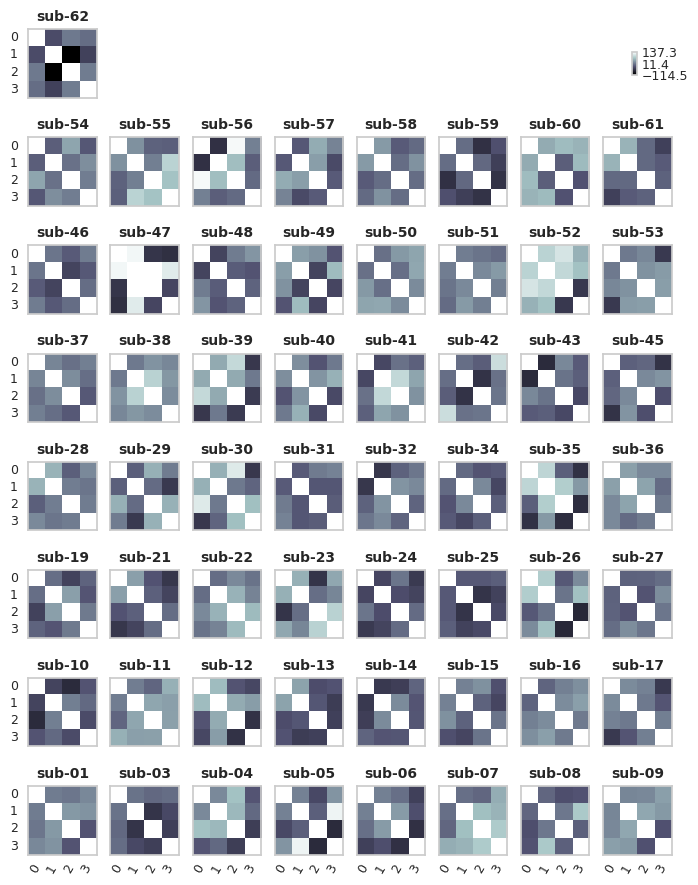

In [10]:
from  rsatoolbox import vis
vis.show_rdm(rdms, rdm_descriptor='subj', show_colorbar='figure', pattern_descriptor='index')

plt.show()

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

Entorhinal-right affordance 0.013010800419751539
Entorhinal-right affordance_magnitude 0.7961442409580681
Entorhinal-right link_distance 0.7428022899860478


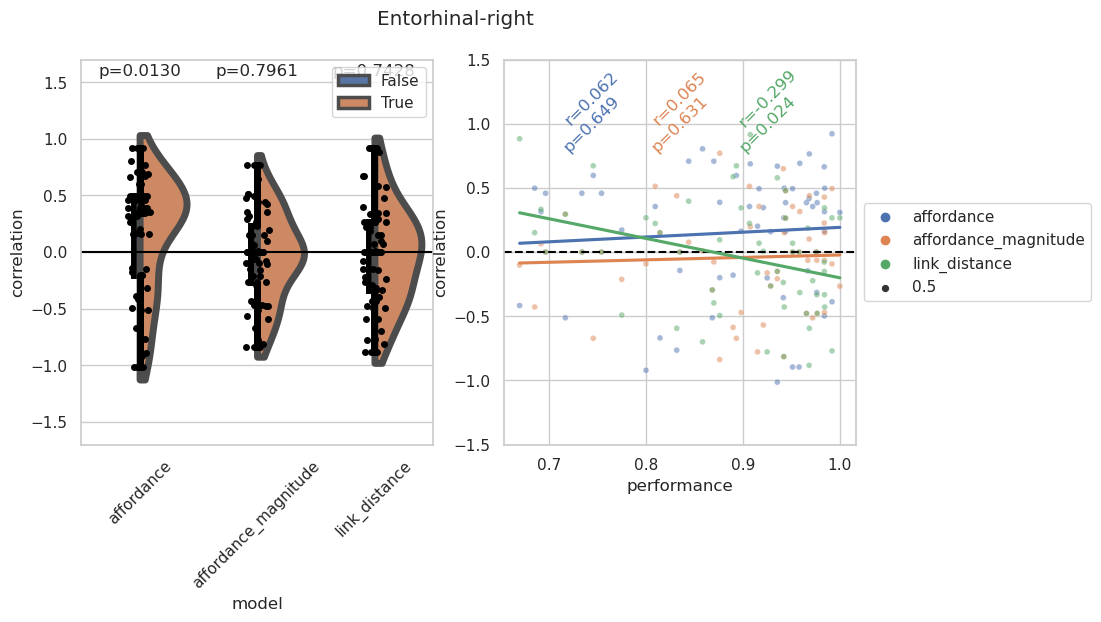

In [11]:

# for each region:

# set sns style to standard
sns.set(style='darkgrid')

# plot violinplot, x = model, y = correlation

# plot scatterplot, x = performance, y = correlation

for region_ in regions:
    region_data = df[df['region'] == region_]

    # exclude -inf and inf values for plotting
    #region_data_plot = region_data[~region_data.isin([np.inf, -np.inf]).any(1)]

    region_data_plot = region_data
    # cut amount is 1-max of correlation
    cut_amount = 1 - np.max(np.abs(region_data['correlation']))
    #print(cut_amount)

    fig, ax = plt.subplots(1, 2, figsize=(20, 20))
    
    # new region data df with no points > 1.5
    region_data_plot = region_data[region_data['correlation'] < 1.5]
    sns.violinplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], cut=0.5,
                   hue=True, hue_order=[False, True], split=True, positions =5.5, native_scale=True, linewidth=5)

    # add points to plot on left of violinplot

    sns.stripplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], color='black', jitter=True, dodge=True)
                  # move points to left side of violinplot

    # add boxplot on left of violinplot

    sns.boxplot(x='model', y='correlation', data=region_data_plot, ax=ax[0], color='black', width=0.1, linewidth=5)

    # add a horizontal line at 0
    ax[0].axhline(0, color='black')

    # max and min are -1.2 and 1.2
    #ax[0].set_ylim(-np.sqrt((57-3) / 1.06) * np.arctanh(0.99), np.sqrt((57-3) / 1.06) * np.arctanh(0.99))
    ax[0].set_ylim(-1.7, 1.7)

    # annotate with p values for ttest >0 (one sample ttest)
    for i in range(len(models)):
        p = ttest_1samp(region_data[region_data['model'] == models[i]]['correlation'], 0, alternative='greater')[1]
        ax[0].annotate(f"p={p:.4f}", xy=(i, 1.6), ha='center', va='center')
        # print region and pval
        print(region_, models[i], p)

    # rortate x labels
    for tick in ax[0].get_xticklabels():
        tick.set_rotation(45)
    

    sns.scatterplot(x='performance', y='correlation', hue='model',data=region_data, ax=ax[1], alpha=0.5, size=0.5)
    # make dots a bit transparent and smaller
    ax[1].axhline(0, ls='--', color='black')
    ax[1].set_ylim(-1.5, 1.5)
    # add line of best fit for each model
    count_x = 1
    # len x is number of models
    len_x = len(models)
    for model_ in models:
        # color is same as scatterplot
        sns.regplot(x='performance', y='correlation', data=region_data_plot[region_data_plot['model'] == model_], ax=ax[1], scatter=False, color=sns.color_palette()[models.index(model_)], ci=0)
        # calculate correlation and p val using pearson
        corr, p = spearmanr(region_data[region_data['model'] == model_]['performance'], region_data[region_data['model'] == model_]['correlation'])
        # add text to plot in legends at top, shifted for each model
        # x coord is a quarter of the way along the x axis
        # get max and min of x axis
        x_min, x_max = ax[1].get_xlim()
        # get x coords of each model
        x_coords = np.linspace(x_min, x_max, len_x+2)
        # get x coord of current model
        x_coord = x_coords[count_x]
        

        ax[1].annotate(f"r={corr:.3f}", xy=(x_coord, 1.2), ha='center', va='center', color=sns.color_palette()[models.index(model_)], rotation=45)
        ax[1].annotate(f"p={p:.3f}", xy=(x_coord, 1), ha='center', va='center', color=sns.color_palette()[models.index(model_)], rotation=45)

        count_x += 1


    # move scatter plot legend to rght of plot and rotate text by 45 degrees
    ax[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

    
    plt.suptitle(region_)
    plt.show()

    # save
    fig.savefig(f'/data/pt_02747/action_hippo/figures/rdm_correlations_{region_}_subs-{len(subs)}{append_str}.png', dpi=300, bbox_inches='tight')

In [38]:
# show correlation values whwere model=affordance and region=hOc1-bilateral
list(df[(df['model'] == 'affordance') & (df['region'] == 'hOc1-bilateral')]['correlation'])

[]

In [14]:
np.arctanh(0.99)

2.6466524123622457

In [9]:
# check difference between models using paired ttest for each region

from scipy.stats import ttest_rel

for region in df['region'].unique():
    print(region)
    print('')
    # get data for region
    region_data = df[df['region'] == region]

    # for each model, do a paired ttest with affordance
    for model in models:
        for model2 in models:
            # do ttest
            t, p = ttest_rel(region_data[region_data['model'] == model]['correlation'], region_data[region_data['model'] == model2]['correlation'])
            if p < 0.05:
                print(model, ' x ', model2)
                print(p)
    print('='*20)


Entorhinal-right

affordance  x  affordance_magnitude
0.026368392773127632
affordance  x  link_distance
0.04020137520117786
affordance_magnitude  x  affordance
0.026368392773127632
link_distance  x  affordance
0.04020137520117786
Entorhinal-left

Entorhinal-bilateral

pACC-bilateral

affordance_magnitude  x  link_distance
0.014616612286342137
link_distance  x  affordance_magnitude
0.014616612286342137
Hippocampus-bilateral

OFC-bilateral

7A-bilateral

affordance  x  link_distance
0.0391337507074054
affordance_magnitude  x  link_distance
0.0013092834401084634
link_distance  x  affordance
0.0391337507074054
link_distance  x  affordance_magnitude
0.0013092834401084634


In [10]:
df.to_csv('/data/pt_02747/action_hippo/data/derivatives/second_level/rdm_correlations_partial.csv', index=False)